In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.stats import wasserstein_distance

T = 20
to = 1
time_steps = np.arange(T)
n_normals = 100
n_radicals = 3
n_counters = 10
beta = 10
alpha = 0.1
epsilon = 0.1
radical_weight = 10
seed_value = 20
rng = np.random.default_rng(seed=seed_value)
initial_opinions = np.clip(rng.normal(loc=0.4, scale=0.2, size=n_normals), 0, 1)

def phi(diff, beta, epsilon):
    return 1 / (1 + np.exp(beta * (abs(diff) - epsilon)))

#radicals_opinions = np.random.rand(T, n_radicals)
radicals_opinions = np.array([[0.63137293, 0.63137719, 0.63136937],
                              [0.63447382, 0.63448284, 0.63453188],
                                [0.63625928, 0.63625713, 0.63626292],
                                [0.63848123, 0.63848769, 0.63849369],
                                [0.64113196, 0.64113442, 0.64112269],
                                [0.64256361, 0.64256366, 0.6425636 ],
                                [0.64459142, 0.64460377, 0.64461509],
                                [0.64409199, 0.64408655, 0.64409998],
                                [0.64470294, 0.64472053, 0.64468694],
                                [0.64481517, 0.64482931, 0.64486877],
                                [0.64531489, 0.64530569, 0.64531739],
                                [0.64437409, 0.64437311, 0.64440009],
                                [0.64432401, 0.64434623, 0.64432482],
                                [0.64421736, 0.64417545, 0.64418519],
                                [0.64253384, 0.64253237, 0.64253418],
                                [0.64200007, 0.6420249,  0.64202426],
                                [0.63993001, 0.63990531, 0.63992934],
                                [0.63914421, 0.63914273, 0.63913838],
                                [0.63838278, 0.63839044, 0.63838675],
                                [0.63770424, 0.63769663, 0.63773718]])

def simulate_continuous_model(opinions_start, counter_radicals, radicals, n_normals, n_radicals, n_counters, duration):
    opinions = opinions_start.copy()
    history = [opinions.copy()]
    for t in range(duration):
        current_radicals = radicals[t]
        current_counters = counter_radicals[t]
        total_opinions = np.concatenate([opinions, current_counters, current_radicals])
        updated_opinions = opinions.copy()
        for i in range(n_normals):
            xi = opinions[i]
            influence_weights = phi(xi - total_opinions, beta, epsilon)
            influence_weights[i] = 0
            influence_weights[-n_radicals - n_counters:] *= radical_weight
            sum_weights = np.sum(influence_weights)
            if sum_weights > 0:
                influence = np.sum(influence_weights * (total_opinions - xi)) / sum_weights
                updated_opinions[i] += alpha * influence
        opinions = np.clip(updated_opinions, 0, 1)
        history.append(opinions.copy())
        
    return opinions, np.array(history)

optimal_counter_strategies = []
current_opinions = initial_opinions.copy()

for t_start in range(0, T, to):
    print("optimising for t =", t_start)
    current_to = min(to, T - t_start)
    if current_to <= 0:
        continue

    previous_opinions = current_opinions.copy()
    radicals_sliced = radicals_opinions[t_start : t_start + current_to]

    def cost(x):
        counter_radicals_to_test = x.reshape((current_to, n_counters))
        final_opinions, _ = simulate_continuous_model(
            previous_opinions, counter_radicals_to_test, radicals_sliced,
            n_normals, n_radicals, n_counters, current_to
        )
        return wasserstein_distance(initial_opinions, final_opinions)

    bounds = [(0, 1)] * (current_to * n_counters)
    result = differential_evolution(cost, bounds, maxiter=40, popsize=15, tol=0.01)

    best_counters_for_period = result.x.reshape((current_to, n_counters))
    optimal_counter_strategies.append(best_counters_for_period)
    
    current_opinions, _ = simulate_continuous_model(
        previous_opinions, best_counters_for_period, radicals_sliced,
        n_normals, n_radicals, n_counters, current_to
    )

final_counter_radicals_strategy = np.vstack(optimal_counter_strategies)


optimising for t = 0
optimising for t = 1
optimising for t = 2
optimising for t = 3
optimising for t = 4
optimising for t = 5
optimising for t = 6
optimising for t = 7
optimising for t = 8
optimising for t = 9
optimising for t = 10
optimising for t = 11
optimising for t = 12
optimising for t = 13
optimising for t = 14
optimising for t = 15
optimising for t = 16
optimising for t = 17
optimising for t = 18
optimising for t = 19


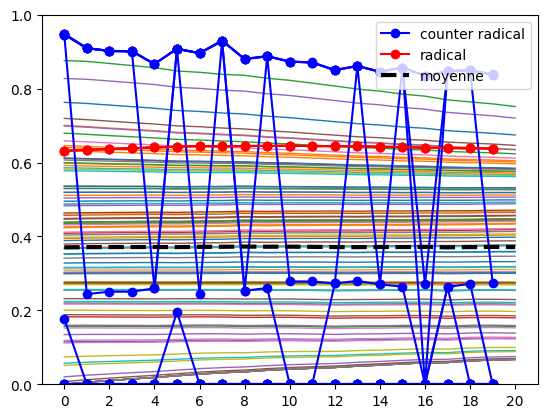

In [19]:
_, historique = simulate_continuous_model(
    initial_opinions,
    final_counter_radicals_strategy,
    radicals_opinions,
    n_normals, n_radicals, n_counters,
    final_counter_radicals_strategy.shape[0]
)

def historique0():
    for agent in range(n_normals):
        plt.plot(historique[:, agent],alpha=1, linewidth=1)
    radicals_strategy = np.sort(final_counter_radicals_strategy)
    radical_opinions_over_time = radicals_strategy[:, 0]
    plt.plot(time_steps, radical_opinions_over_time, marker='o', linestyle='-', color = 'blue', label = 'counter radical')
    for i in range(1,n_counters):
        radical_opinions_over_time = radicals_strategy[:, i]
        plt.plot(time_steps, radical_opinions_over_time, marker='o', linestyle='-', color = 'blue')
    radicals = np.sort(radicals_opinions)
    radical_opinions_over_time = radicals[:, 0]
    plt.plot(time_steps, radical_opinions_over_time, marker='o', linestyle='-', color = 'red', label = 'radical')
    for i in range(1, n_radicals):
        radical_opinions_over_time = radicals[:, i]
        plt.plot(time_steps, radical_opinions_over_time, marker='o', linestyle='-', color = 'red')
    moyenne = np.mean(historique, axis=1)
    plt.plot(moyenne, color='black',linestyle='--', linewidth=3, label = 'moyenne')
    plt.ylim(0, 1)
    plt.xticks(np.arange(0, T + 1, 2))
    plt.legend()
    plt.show()

historique0()